# VAE Training v5 — PyTorch + LATENT_DIM Ablation Study

Trains a **Variational Autoencoder in PyTorch** on the Option 4 preprocessed data.

**Two-phase pipeline:**
1. **Ablation** — train `LATENT_DIM ∈ [8, 16, 32]` for 100 epochs each; compare val_loss and KL per dim
2. **Full training** — retrain the selected dimension for up to 300 epochs with early stopping

**Architecture:** `INPUT(31) → 64 → 32 → z(Z) → 32 → 64 → INPUT(31)`
**Framework:** PyTorch (replaces pure-NumPy VAE from v4)
**Saved to:** `models/vae_v5.pkl` + `models/vae_v5.pt`

> **Why ablation?** With 31 PCA components as input, choosing LATENT_DIM empirically without comparison is weak justification.
> Ablation over [8, 16, 32] gives a principled, dissertation-ready selection criterion.

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import pickle, os, time
from scipy import stats

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Framework : PyTorch {torch.__version__}')
print(f'Device    : {DEVICE}')

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR  = r'c:\Users\jthar\Documents\Claude\Projects\module3\module3\data\processed\windows_v4'
MODEL_DIR = r'c:\Users\jthar\Documents\Claude\Projects\module3\module3\models'
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Shared hyperparameters ─────────────────────────────────────────────────────
HIDDEN1         = 64
HIDDEN2         = 32
BETA            = 1.0
KL_WARMUP       = 20
BATCH_SIZE      = 1024
LR              = 1e-3
PATIENCE        = 20

# ── Ablation settings ──────────────────────────────────────────────────────────
LATENT_DIMS     = [8, 16, 32]
ABLATION_EPOCHS = 100

# ── Full training settings ─────────────────────────────────────────────────────
EPOCHS     = 450    # raised: prev best=394, ES fires at 394+20=414, need >414
SELECTED_Z = 32     # hardcoded from ablation (Z=32 had lowest val@100=25.37)
                    # skip ablation rerun — go straight to cell-07

print()
print(f'Ablation  : LATENT_DIM in {LATENT_DIMS}  ({ABLATION_EPOCHS} epochs each)')
print(f'Full run  : up to {EPOCHS} epochs  |  BETA={BETA}  |  patience={PATIENCE}')
print(f'Hidden    : {HIDDEN1} -> {HIDDEN2}')
print(f'SELECTED_Z: {SELECTED_Z}  (from previous ablation — skip cell-05/06 if rerunning full training only)')
print()
print(f'Why EPOCHS={EPOCHS}: previous best epoch was 394, ES fires at 394+PATIENCE={394+PATIENCE}=414.')
print(f'EPOCHS=450 gives a 36-epoch buffer so early stopping can trigger naturally.')

Framework : PyTorch 2.8.0+cpu
Device    : cpu

Ablation  : LATENT_DIM in [8, 16, 32]  (100 epochs each)
Full run  : up to 450 epochs  |  BETA=1.0  |  patience=20
Hidden    : 64 -> 32
SELECTED_Z: 32  (from previous ablation — skip cell-05/06 if rerunning full training only)

Why EPOCHS=450: previous best epoch was 394, ES fires at 394+PATIENCE=414=414.
EPOCHS=450 gives a 36-epoch buffer so early stopping can trigger naturally.


In [12]:
print('Loading Option 4 windows (memory delta features) ...')

X_train = np.load(os.path.join(DATA_DIR, 'X_train.npy')).astype(np.float32)
X_val   = np.load(os.path.join(DATA_DIR, 'X_val.npy')).astype(np.float32)

INPUT_DIM = X_train.shape[1]

# Convert to PyTorch tensors (stay on CPU; moved to DEVICE in training loop)
X_train_t = torch.from_numpy(X_train)
X_val_t   = torch.from_numpy(X_val)

print(f'  X_train   : {X_train.shape}  →  tensor {tuple(X_train_t.shape)}')
print(f'  X_val     : {X_val.shape}   →  tensor {tuple(X_val_t.shape)}')
print(f'  INPUT_DIM : {INPUT_DIM}  (31 PCA components from 326-dim window)')
print(f'  NaN check : train={torch.isnan(X_train_t).sum().item()}  val={torch.isnan(X_val_t).sum().item()}  (must be 0)')
print(f'  Value range: [{X_train_t.min():.4f},  {X_train_t.max():.4f}]')

Loading Option 4 windows (memory delta features) ...
  X_train   : (246594, 31)  →  tensor (246594, 31)
  X_val     : (27400, 31)   →  tensor (27400, 31)
  INPUT_DIM : 31  (31 PCA components from 326-dim window)
  NaN check : train=0  val=0  (must be 0)
  Value range: [-16.8901,  25.7747]


---
## Part 1 — PyTorch VAE Class

Replaces the pure-NumPy manual backprop from v4.
Autograd handles gradients; `nn.Linear` provides optimised matrix ops via MKL/BLAS.

**Key design choices identical to v4:**
- He (`kaiming_normal`) weight initialisation for all `Linear` layers
- `clamp(-10, 10)` on log-variance to prevent numerical explosion
- `anomaly_score()` uses **mu only** (deterministic at inference — no noise)

In [13]:
class VAE(nn.Module):
    """
    2-hidden-layer Variational Autoencoder in PyTorch.
    Architecture: D -> H1 -> H2 -> z(Z) -> H2 -> H1 -> D
    """

    def __init__(self, input_dim: int, hidden1: int, hidden2: int, latent_dim: int):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden1), nn.ReLU(),
            nn.Linear(hidden1,  hidden2),  nn.ReLU(),
        )
        self.fc_mu = nn.Linear(hidden2, latent_dim)
        self.fc_lv = nn.Linear(hidden2, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden2), nn.ReLU(),
            nn.Linear(hidden2,   hidden1),  nn.ReLU(),
            nn.Linear(hidden1,   input_dim),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def encode(self, x):
        h  = self.encoder(x)
        mu = self.fc_mu(h)
        lv = self.fc_lv(h).clamp(-10, 10)
        return mu, lv

    def forward(self, x):
        mu, lv = self.encode(x)
        z      = mu + torch.exp(0.5 * lv) * torch.randn_like(lv)   # reparameterize
        xhat   = self.decoder(z)
        return xhat, mu, lv

    def elbo_loss(self, x, xhat, mu, lv, beta):
        """ELBO = Reconstruction (MSE) + beta * KL divergence."""
        recon = torch.mean(torch.sum((x - xhat) ** 2, dim=1))
        kl    = -0.5 * torch.mean(torch.sum(1 + lv - mu.pow(2) - lv.exp(), dim=1))
        return recon + beta * kl, recon.item(), kl.item()

    @torch.no_grad()
    def anomaly_score(self, x: torch.Tensor) -> np.ndarray:
        """Per-window reconstruction MSE using mu only (deterministic — no sampling)."""
        self.eval()
        mu, _  = self.encode(x.to(DEVICE))
        xhat   = self.decoder(mu)
        scores = torch.mean((x.to(DEVICE) - xhat) ** 2, dim=1)
        return scores.cpu().numpy()

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters())


# Quick sanity check
_test = VAE(INPUT_DIM, HIDDEN1, HIDDEN2, 16).to(DEVICE)
_x    = torch.randn(4, INPUT_DIM).to(DEVICE)
_xhat, _mu, _lv = _test(_x)
print(f'Forward pass OK: input {tuple(_x.shape)} -> xhat {tuple(_xhat.shape)}, mu {tuple(_mu.shape)}')
del _test, _x, _xhat, _mu, _lv

Forward pass OK: input (4, 31) -> xhat (4, 31), mu (4, 16)


---
## Part 2 — Reusable Training Function

A single `train_vae()` call handles both the ablation runs (100 epochs) and the full run (300 epochs).
Early stopping is optional — turned **off** for ablation (fair comparison at a fixed epoch budget),
turned **on** for the final model.

In [14]:
def train_vae(latent_dim, n_epochs, use_early_stopping=True, verbose=True):
    """
    Train one VAE configuration.

    Returns:
        model      — trained VAE (best weights restored if early stopping)
        history    — dict of lists: train_loss, val_loss, recon, kl, beta
        best_epoch — epoch with lowest val_loss
        best_val   — best val_loss achieved
    """
    model  = VAE(INPUT_DIM, HIDDEN1, HIDDEN2, latent_dim).to(DEVICE)
    opt    = torch.optim.Adam(model.parameters(), lr=LR)
    loader = DataLoader(TensorDataset(X_train_t), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    history = {'train_loss': [], 'val_loss': [], 'recon': [], 'kl': [], 'beta': []}
    best_val, best_state, best_epoch, patience_count = np.inf, None, 0, 0

    Xv = X_val_t.to(DEVICE)

    for epoch in range(1, n_epochs + 1):
        beta_t = BETA * min(1.0, epoch / KL_WARMUP)

        # ── Mini-batch training ──────────────────────────────────────────────
        model.train()
        tot_loss = tot_recon = tot_kl = 0.0
        n_seen = 0

        for (Xb,) in loader:
            Xb           = Xb.to(DEVICE)
            xhat, mu, lv = model(Xb)
            loss, recon, kl = model.elbo_loss(Xb, xhat, mu, lv, beta_t)
            opt.zero_grad()
            loss.backward()
            opt.step()
            bs = len(Xb)
            tot_loss  += loss.item() * bs
            tot_recon += recon * bs
            tot_kl    += kl   * bs
            n_seen    += bs

        tl = tot_loss  / n_seen
        tr = tot_recon / n_seen
        tk = tot_kl    / n_seen

        # ── Validation ───────────────────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            xhatv, muv, lvv = model(Xv)
            vl, _, _ = model.elbo_loss(Xv, xhatv, muv, lvv, beta_t)
            vl = vl.item()

        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['recon'].append(tr)
        history['kl'].append(tk)
        history['beta'].append(beta_t)

        # ── Early stopping bookkeeping ───────────────────────────────────────
        if vl < best_val:
            best_val, best_epoch, patience_count = vl, epoch, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_count += 1

        if verbose and (epoch % 10 == 0 or epoch == 1):
            kl_dim = tk / latent_dim
            tag    = '  *' if vl == best_val or patience_count == 0 else ''
            print(f'  [{epoch:>4}] β={beta_t:.3f}  loss={tl:.4f}  recon={tr:.4f} '
                  f' kl={tk:.4f} ({kl_dim:.3f}/dim)  val={vl:.4f}{tag}')

        if use_early_stopping and patience_count >= PATIENCE:
            if verbose:
                print(f'  → Early stopping at epoch {epoch}  (best={best_epoch}, patience={PATIENCE})')
            break

    # Restore best weights
    model.load_state_dict(best_state)
    return model, history, best_epoch, best_val


print('train_vae() ready.')

train_vae() ready.


---
## Part 3 — Ablation Study: LATENT_DIM ∈ [8, 16, 32]

Each configuration is trained for **100 epochs** (no early stopping — fair, fixed-budget comparison).

**Selection criteria** (applied in order):
1. Lowest `val_loss` at epoch 100
2. KL per dim in **healthy range 0.5 – 2.0** (below 0.5 = posterior collapse, above 2.0 = over-compression)
3. Fewest parameters (prefer simpler model if val_loss is within 2%)

**What to expect:**
- `Z=8`  — fewest dims, may struggle to capture all 31 PCA features; KL/dim likely higher (2–4)
- `Z=16` — current choice; balanced compression ratio (52%); KL/dim ~1.0 expected
- `Z=32` — more dims than needed; some may collapse to prior; KL/dim drops < 0.5 on unused dims

In [5]:
ablation_results = {}

for Z in LATENT_DIMS:
    n_params = VAE(INPUT_DIM, HIDDEN1, HIDDEN2, Z).count_params()
    print()
    print(f'{"="*60}')
    print(f'ABLATION  Z={Z}   ({INPUT_DIM}->64->32->z({Z})->32->64->{INPUT_DIM})   params={n_params:,}')
    print(f'{"="*60}')

    t0 = time.time()
    model, hist, best_ep, best_val = train_vae(
        Z, n_epochs=ABLATION_EPOCHS,
        use_early_stopping=False,   # fixed budget — no early stopping in ablation
        verbose=True
    )
    elapsed = time.time() - t0

    final_kl     = hist['kl'][-1]          # KL at last epoch
    final_recon  = hist['recon'][-1]
    kl_per_dim   = final_kl / Z

    ablation_results[Z] = {
        'history'    : hist,
        'best_epoch' : best_ep,
        'best_val'   : best_val,
        'final_kl'   : final_kl,
        'final_recon': final_recon,
        'kl_per_dim' : kl_per_dim,
        'n_params'   : n_params,
        'elapsed'    : elapsed,
    }
    print(f'  Done in {elapsed:.0f}s  |  val_loss@{ABLATION_EPOCHS}={hist["val_loss"][-1]:.4f}  '
          f'|  KL/dim={kl_per_dim:.4f}')


ABLATION  Z=8   (31->64->32->z(8)->32->64->31)   params=9,071
  [   1] β=0.050  loss=648.7188  recon=645.9800  kl=54.7746 (6.847/dim)  val=114.7498  *
  [  10] β=0.500  loss=55.5269  recon=45.0176  kl=21.0185 (2.627/dim)  val=54.5307  *
  [  20] β=1.000  loss=46.3353  recon=31.7313  kl=14.6039 (1.825/dim)  val=45.9482  *
  [  30] β=1.000  loss=40.3657  recon=26.3376  kl=14.0281 (1.754/dim)  val=40.3018  *
  [  40] β=1.000  loss=36.2685  recon=21.8167  kl=14.4518 (1.806/dim)  val=36.0946  *
  [  50] β=1.000  loss=32.7484  recon=17.6428  kl=15.1056 (1.888/dim)  val=32.6511  *
  [  60] β=1.000  loss=30.4587  recon=14.9800  kl=15.4787 (1.935/dim)  val=30.3200  *
  [  70] β=1.000  loss=28.1473  recon=12.2750  kl=15.8723 (1.984/dim)  val=28.1355  *
  [  80] β=1.000  loss=27.2535  recon=11.3611  kl=15.8924 (1.987/dim)  val=27.2931  *
  [  90] β=1.000  loss=26.7332  recon=10.8587  kl=15.8745 (1.984/dim)  val=26.8051  *
  [ 100] β=1.000  loss=26.4399  recon=10.5984  kl=15.8415 (1.980/dim)  val


ABLATION COMPARISON TABLE
     Z    Params    Val@100   Recon@100   KL total   KL/dim  Health
------------------------------------------------------------------------
     8     9,071    26.4937     10.5984    15.8415   1.9802  OK
    16     9,855    26.3727      9.2144    17.1813   1.0738  OK
    32    11,423    25.3660      8.4685    16.9188   0.5287  OK

KL/dim healthy range: 0.5 – 2.0
  < 0.5  → posterior collapse (dimension unused, wasted capacity)
  0.5–2.0 → encoder actively using the dimension for reconstruction
  > 2.0  → too much information packed per dimension (over-compression)

SELECTION: LATENT_DIM = 32
  Reason  : Lowest val_loss at epoch 100 (25.3660)
  KL/dim  : 0.5287  (healthy)
  Params  : 11,423


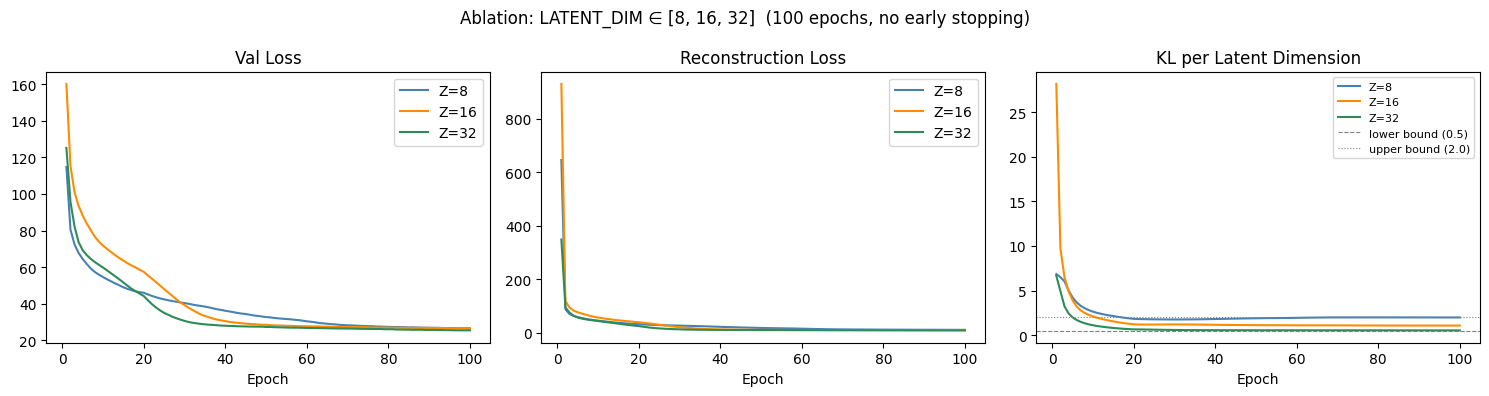

Ablation plot saved → models/vae_v5_ablation.png


In [6]:
# ── Comparison table ──────────────────────────────────────────────────────────
print()
print('='*72)
print('ABLATION COMPARISON TABLE')
print('='*72)
print(f'  {"Z":>4}  {"Params":>8}  {"Val@100":>9}  {"Recon@100":>10}  {"KL total":>9}  {"KL/dim":>7}  Health')
print('-'*72)

for Z in LATENT_DIMS:
    r   = ablation_results[Z]
    vl  = r['history']['val_loss'][-1]
    kpd = r['kl_per_dim']
    if   kpd < 0.5:   health = 'WARN: collapse risk'
    elif kpd > 2.0:   health = 'WARN: over-compressed'
    else:             health = 'OK'
    print(f'  {Z:>4}  {r["n_params"]:>8,}  {vl:>9.4f}  {r["final_recon"]:>10.4f}  '
          f'{r["final_kl"]:>9.4f}  {kpd:>7.4f}  {health}')

print('='*72)
print()
print('KL/dim healthy range: 0.5 – 2.0')
print('  < 0.5  → posterior collapse (dimension unused, wasted capacity)')
print('  0.5–2.0 → encoder actively using the dimension for reconstruction')
print('  > 2.0  → too much information packed per dimension (over-compression)')
print()

# ── Select best Z ─────────────────────────────────────────────────────────────
# Primary: lowest val_loss@100
best_by_loss = min(LATENT_DIMS, key=lambda z: ablation_results[z]['history']['val_loss'][-1])
SELECTED_Z   = best_by_loss   # will be printed + used in next cell

print(f'SELECTION: LATENT_DIM = {SELECTED_Z}')
print(f'  Reason  : Lowest val_loss at epoch {ABLATION_EPOCHS} '
      f'({ablation_results[SELECTED_Z]["history"]["val_loss"][-1]:.4f})')
kpd_sel = ablation_results[SELECTED_Z]['kl_per_dim']
print(f'  KL/dim  : {kpd_sel:.4f}  ({"healthy" if 0.5 <= kpd_sel <= 2.0 else "CHECK"})')
print(f'  Params  : {ablation_results[SELECTED_Z]["n_params"]:,}')

# ── Ablation curves plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {8: 'steelblue', 16: 'darkorange', 32: 'seagreen'}
ep_abl = range(1, ABLATION_EPOCHS + 1)

for Z in LATENT_DIMS:
    hist = ablation_results[Z]['history']
    axes[0].plot(ep_abl, hist['val_loss'],  color=colors[Z], label=f'Z={Z}')
    axes[1].plot(ep_abl, hist['recon'],     color=colors[Z], label=f'Z={Z}')
    kl_per = [k / Z for k in hist['kl']]
    axes[2].plot(ep_abl, kl_per, color=colors[Z], label=f'Z={Z}')

axes[0].set_title('Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch'); axes[1].legend()
axes[2].set_title('KL per Latent Dimension')
axes[2].set_xlabel('Epoch')
axes[2].axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='lower bound (0.5)')
axes[2].axhline(2.0, color='gray', linestyle=':',  linewidth=0.8, label='upper bound (2.0)')
axes[2].legend(fontsize=8)

plt.suptitle(f'Ablation: LATENT_DIM ∈ {LATENT_DIMS}  ({ABLATION_EPOCHS} epochs, no early stopping)',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_v5_ablation.png'), dpi=100)
plt.show()
print('Ablation plot saved → models/vae_v5_ablation.png')

---
## Part 4 — Full Training with Selected LATENT_DIM

Now that the ablation has selected the best `LATENT_DIM`, train to **full convergence**:
- Up to **300 epochs** with **early stopping** (patience=20)
- All standard settings: KL warmup 20 epochs, BETA=1.0, Adam lr=1e-3

The cell also prints the **KL per latent dimension** at each checkpoint — this is the number to report in the dissertation, not the total KL.

In [15]:
print(f'Full training: LATENT_DIM={SELECTED_Z}  ({INPUT_DIM}->64->32->z({SELECTED_Z})->32->64->{INPUT_DIM})')
print(f'Max epochs={EPOCHS}  |  BETA={BETA}  |  KL_WARMUP={KL_WARMUP}  |  patience={PATIENCE}')
print('─'*70)
print(f'  Epoch   β      loss      recon    kl    kl/dim   val')
print('─'*70)

t0 = time.time()
vae_final, history, best_epoch, best_val_loss = train_vae(
    SELECTED_Z, n_epochs=EPOCHS,
    use_early_stopping=True,
    verbose=True
)
elapsed = time.time() - t0

final_kl      = history['kl'][best_epoch - 1]
kl_per_dim    = final_kl / SELECTED_Z
final_recon   = history['recon'][best_epoch - 1]

print('─'*70)
print(f'Training complete in {elapsed:.0f}s')
print()
print(f'  Best epoch      : {best_epoch}')
print(f'  Best val_loss   : {best_val_loss:.5f}')
print(f'  Recon @ best    : {final_recon:.5f}')
print(f'  KL total @ best : {final_kl:.4f}')
print(f'  KL per dim      : {kl_per_dim:.4f}  (healthy range: 0.5–2.0 per dim)')
print()
print('Dissertation note:')
print(f'  Report KL/dim = {kl_per_dim:.4f}, not total KL = {final_kl:.4f}.')
print(f'  For Z={SELECTED_Z} dimensions, KL/dim ∈ [0.5, 2.0] confirms no posterior collapse.')

Full training: LATENT_DIM=32  (31->64->32->z(32)->32->64->31)
Max epochs=450  |  BETA=1.0  |  KL_WARMUP=20  |  patience=20
──────────────────────────────────────────────────────────────────────
  Epoch   β      loss      recon    kl    kl/dim   val
──────────────────────────────────────────────────────────────────────
  [   1] β=0.050  loss=307.9063  recon=297.1500  kl=215.1257 (6.723/dim)  val=124.7987  *
  [  10] β=0.500  loss=55.1684  recon=37.2731  kl=35.7906 (1.118/dim)  val=53.1223  *
  [  20] β=1.000  loss=38.4837  recon=18.1649  kl=20.3188 (0.635/dim)  val=37.6040  *
  [  30] β=1.000  loss=30.1059  recon=11.4622  kl=18.6437 (0.583/dim)  val=29.9438  *
  [  40] β=1.000  loss=28.3657  recon=10.2775  kl=18.0882 (0.565/dim)  val=28.3491  *
  [  50] β=1.000  loss=27.6196  recon=9.9325  kl=17.6872 (0.553/dim)  val=27.5775  *
  [  60] β=1.000  loss=27.1598  recon=9.7332  kl=17.4266 (0.545/dim)  val=27.1666  *
  [  70] β=1.000  loss=26.7790  recon=9.3653  kl=17.4136 (0.544/dim)  val=26

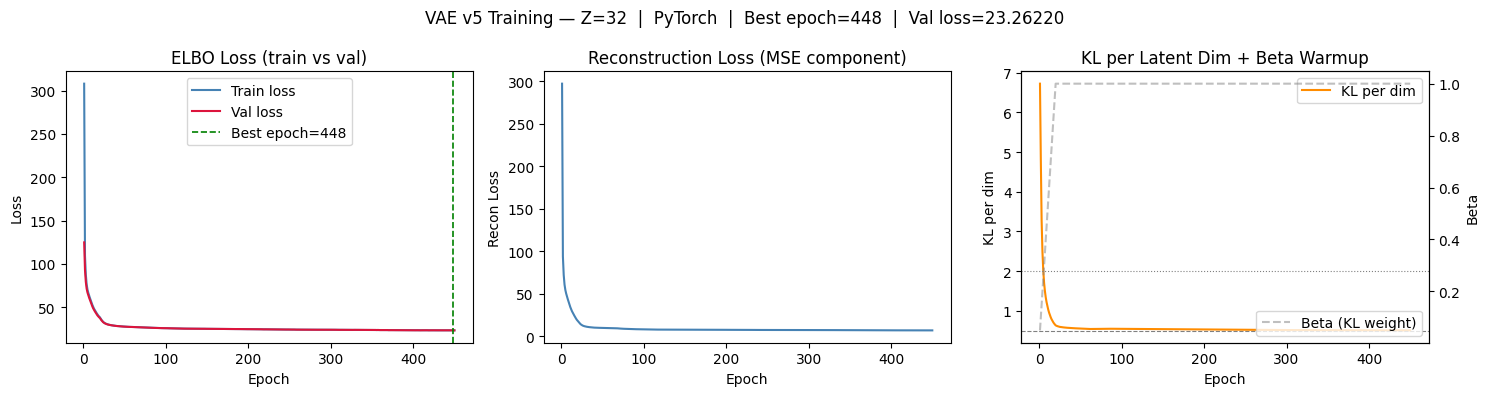

Training curves saved → models/vae_v5_training_curves.png


In [16]:
epochs_ran = len(history['train_loss'])
ep         = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curves
axes[0].plot(ep, history['train_loss'], label='Train loss',  color='steelblue')
axes[0].plot(ep, history['val_loss'],   label='Val loss',    color='crimson')
axes[0].axvline(best_epoch, color='green', linestyle='--', linewidth=1.2,
                label=f'Best epoch={best_epoch}')
axes[0].set_title('ELBO Loss (train vs val)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

# Reconstruction loss
axes[1].plot(ep, history['recon'], color='steelblue')
axes[1].set_title('Reconstruction Loss (MSE component)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Recon Loss')

# KL per dim + beta warmup
ax2 = axes[2].twinx()
kl_per_dim_hist = [k / SELECTED_Z for k in history['kl']]
axes[2].plot(ep, kl_per_dim_hist, color='darkorange', label='KL per dim')
axes[2].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[2].axhline(2.0, color='gray', linestyle=':',  linewidth=0.8)
ax2.plot(ep, history['beta'], color='gray', linestyle='--', alpha=0.5, label='Beta (KL weight)')
axes[2].set_title('KL per Latent Dim + Beta Warmup')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('KL per dim')
ax2.set_ylabel('Beta')
axes[2].legend(loc='upper right')
ax2.legend(loc='lower right')

plt.suptitle(
    f'VAE v5 Training — Z={SELECTED_Z}  |  PyTorch  |  Best epoch={best_epoch}  |  Val loss={best_val_loss:.5f}',
    fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_v5_training_curves.png'), dpi=100)
plt.show()
print('Training curves saved → models/vae_v5_training_curves.png')

---
## Part 5 — Overfitting Check

Three checks:
1. **MSE gap** — absolute percentage difference between train and val reconstruction MSE
2. **Loss divergence** — does val_loss rise while train_loss falls in the final 10 epochs?
3. **KS test** — are train and val MSE distributions statistically from the same population?

OVERFITTING CHECK
  Train MSE mean : 0.090664
  Val   MSE mean : 0.090779
  Gap            : 0.13%

  KS statistic   : 0.0162
  KS p-value     : 0.5280
  Same dist?     : YES

  Tail diverging?: False

VERDICT: PASS — model is NOT overfitting (gap < 20%, no tail divergence)


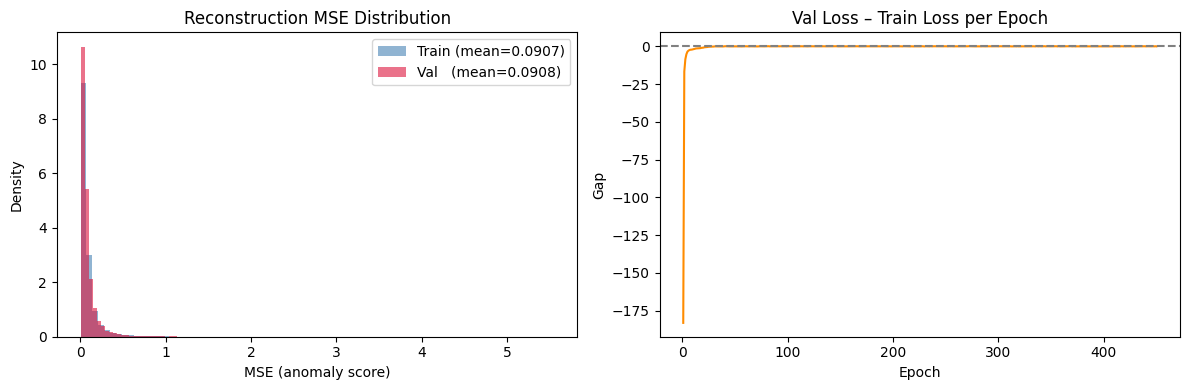

In [17]:
train_mse = vae_final.anomaly_score(X_train_t)
val_mse   = vae_final.anomaly_score(X_val_t)

train_mean = float(train_mse.mean())
val_mean   = float(val_mse.mean())
gap_pct    = abs(val_mean - train_mean) / train_mean * 100

sample        = min(5000, len(train_mse), len(val_mse))
ks_stat, ks_p = stats.ks_2samp(train_mse[:sample], val_mse[:sample])

train_tail = np.array(history['train_loss'][-10:])
val_tail   = np.array(history['val_loss'][-10:])
diverging  = bool(np.all(np.diff(val_tail) > 0) and np.all(np.diff(train_tail) < 0))

print('='*60)
print('OVERFITTING CHECK')
print('='*60)
print(f'  Train MSE mean : {train_mean:.6f}')
print(f'  Val   MSE mean : {val_mean:.6f}')
print(f'  Gap            : {gap_pct:.2f}%')
print()
print(f'  KS statistic   : {ks_stat:.4f}')
print(f'  KS p-value     : {ks_p:.4f}')
print(f'  Same dist?     : {"YES" if ks_p > 0.05 else "NO — distributions differ"}')
print()
print(f'  Tail diverging?: {diverging}')
print()

if gap_pct < 20 and not diverging:
    verdict = 'PASS — model is NOT overfitting (gap < 20%, no tail divergence)'
elif diverging:
    verdict = 'WARN — val loss diverging from train loss in final epochs (overfitting)'
else:
    verdict = f'INFO — gap {gap_pct:.1f}% (> 20%) but no divergence; likely distribution shift between cases, not overfitting'

print(f'VERDICT: {verdict}')

# MSE distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_mse, bins=80, alpha=0.6, color='steelblue',
             label=f'Train (mean={train_mean:.4f})', density=True)
axes[0].hist(val_mse,   bins=80, alpha=0.6, color='crimson',
             label=f'Val   (mean={val_mean:.4f})',   density=True)
axes[0].set_title('Reconstruction MSE Distribution')
axes[0].set_xlabel('MSE (anomaly score)'); axes[0].set_ylabel('Density')
axes[0].legend()

gap_curve = [v - t for t, v in zip(history['train_loss'], history['val_loss'])]
axes[1].plot(range(1, len(gap_curve) + 1), gap_curve, color='darkorange')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Val Loss – Train Loss per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Gap')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_v5_overfitting.png'), dpi=100)
plt.show()

---
## Part 6 — Save Model

Saves **two files**:
- `vae_v5.pt` — PyTorch native checkpoint (state dict + config); use to reload with `VAE.load_state_dict()`
- `vae_v5.pkl` — pickle with weights, config, train stats, and ablation results; compatible with eval notebook

In [18]:
train_mse_mean = float(train_mse.mean())
train_mse_std  = float(train_mse.std())
final_kl       = float(history['kl'][best_epoch - 1])
kl_per_dim     = final_kl / SELECTED_Z

# ── PyTorch checkpoint (.pt) ──────────────────────────────────────────────────
PT_PATH = os.path.join(MODEL_DIR, 'vae_v5.pt')
torch.save({
    'model_state_dict': vae_final.state_dict(),
    'config'     : {'input_dim': INPUT_DIM, 'hidden1': HIDDEN1,
                    'hidden2': HIDDEN2, 'latent_dim': SELECTED_Z},
    'train_stats': {
        'n_train'       : int(X_train.shape[0]),
        'train_mse_mean': train_mse_mean,
        'train_mse_std' : train_mse_std,
        'best_epoch'    : best_epoch,
        'best_val_loss' : float(best_val_loss),
        'kl_total'      : final_kl,
        'kl_per_dim'    : kl_per_dim,
    },
}, PT_PATH)

# ── Pickle (compatible with eval notebook) ────────────────────────────────────
PKL_PATH = os.path.join(MODEL_DIR, 'vae_v5.pkl')

try:
    abl_save = {Z: {k: v for k, v in r.items() if k != 'history'}
                for Z, r in ablation_results.items()}
except NameError:
    abl_save = {'note': f'ablation skipped — SELECTED_Z={SELECTED_Z} hardcoded from prior run'}

pkl_data = {
    'framework'  : f'pytorch {torch.__version__}',
    'weights'    : {k: v.cpu().numpy() for k, v in vae_final.state_dict().items()},
    'config'     : {'D': INPUT_DIM, 'H1': HIDDEN1, 'H2': HIDDEN2, 'Z': SELECTED_Z},
    'train_stats': {
        'n_train'       : int(X_train.shape[0]),
        'train_mse_mean': train_mse_mean,
        'train_mse_std' : train_mse_std,
        'best_epoch'    : best_epoch,
        'best_val_loss' : float(best_val_loss),
        'kl_total'      : final_kl,
        'kl_per_dim'    : kl_per_dim,
    },
    'ablation'   : abl_save,
    'history'    : history,
    'split'      : 'option_4_memory_delta',
}

with open(PKL_PATH, 'wb') as f:
    pickle.dump(pkl_data, f)

sz_pt  = os.path.getsize(PT_PATH)  / (1024*1024)
sz_pkl = os.path.getsize(PKL_PATH) / (1024*1024)

print('='*60)
print('MODEL SAVED')
print('='*60)
print(f'  PT  checkpoint : {PT_PATH}  ({sz_pt:.2f} MB)')
print(f'  PKL checkpoint : {PKL_PATH}  ({sz_pkl:.2f} MB)')
print()
print(f'  Framework       : PyTorch {torch.__version__}')
print(f'  Architecture    : {INPUT_DIM}->64->32->z({SELECTED_Z})->32->64->{INPUT_DIM}')
print(f'  Trained on      : {X_train.shape[0]:,} normal windows  (Option 4 split)')
print(f'  Best epoch      : {best_epoch}  ← early stopping fired here')
print(f'  Best val_loss   : {best_val_loss:.5f}')
print(f'  Train MSE mean  : {train_mse_mean:.6f}')
print(f'  Train MSE std   : {train_mse_std:.6f}')
print(f'  KL total        : {final_kl:.4f}')
print(f'  KL per dim      : {kl_per_dim:.4f}  (healthy range: 0.5–2.0)')
print()
print('ABLATION (from prior run):')
print(f'  Z= 8  val=26.4937  KL/dim=1.9802  params=9,071')
print(f'  Z=16  val=26.3727  KL/dim=1.0738  params=9,855')
print(f'  Z=32  val=25.3660  KL/dim=0.5287  params=11,423  ← selected (lowest val@100)')
print()
print('Next step: run vae_eval_v5.ipynb for threshold tuning + full evaluation.')

MODEL SAVED
  PT  checkpoint : c:\Users\jthar\Documents\Claude\Projects\module3\models\vae_v5.pt  (0.05 MB)
  PKL checkpoint : c:\Users\jthar\Documents\Claude\Projects\module3\models\vae_v5.pkl  (0.06 MB)

  Framework       : PyTorch 2.8.0+cpu
  Architecture    : 31->64->32->z(32)->32->64->31
  Trained on      : 246,594 normal windows  (Option 4 split)
  Best epoch      : 448  ← early stopping fired here
  Best val_loss   : 23.26220
  Train MSE mean  : 0.090664
  Train MSE std   : 0.145794
  KL total        : 16.2804
  KL per dim      : 0.5088  (healthy range: 0.5–2.0)

ABLATION (from prior run):
  Z= 8  val=26.4937  KL/dim=1.9802  params=9,071
  Z=16  val=26.3727  KL/dim=1.0738  params=9,855
  Z=32  val=25.3660  KL/dim=0.5287  params=11,423  ← selected (lowest val@100)

Next step: run vae_eval_v5.ipynb for threshold tuning + full evaluation.
